In [21]:
import pandas as pd

# Load dataset
df = pd.read_csv("q1_heart_disease.csv")

# Display shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# First 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


The dataset contains patient health-related attributes such as age, cholesterol, and heart rate. The target variable heart_disease indicates whether a patient has heart disease (1) or not (0). Initial inspection helps identify data types and missing values, which are important for preprocessing.

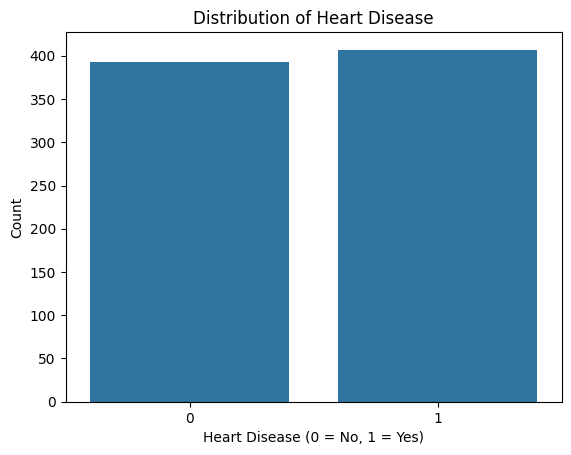

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The plot shows the distribution of patients with and without heart disease. If the classes are balanced, models can learn effectively; otherwise, imbalance may require special handling.

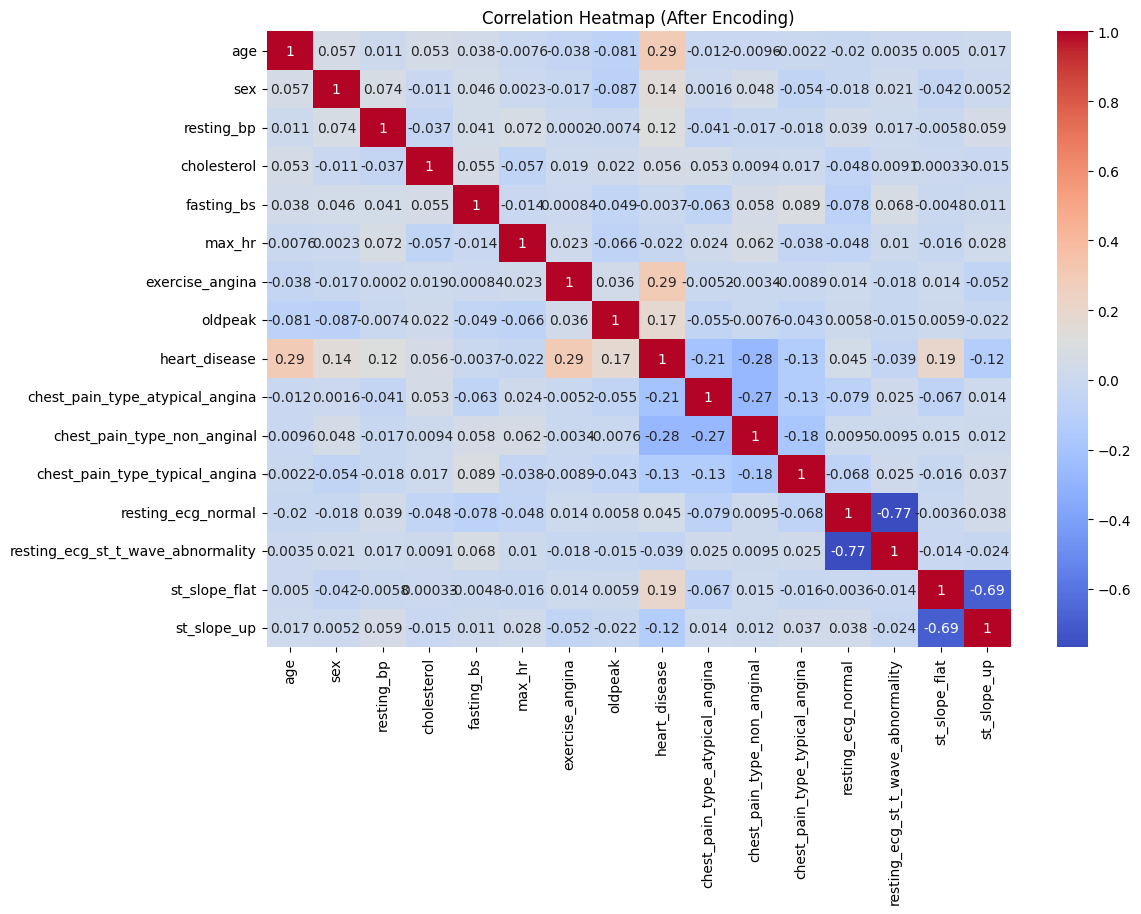

In [24]:
# Convert categorical columns using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (After Encoding)")
plt.show()

The heatmap highlights relationships between variables. Features such as oldpeak, max_hr, and chest_pain_type often show stronger correlations with heart disease, indicating their importance in prediction.

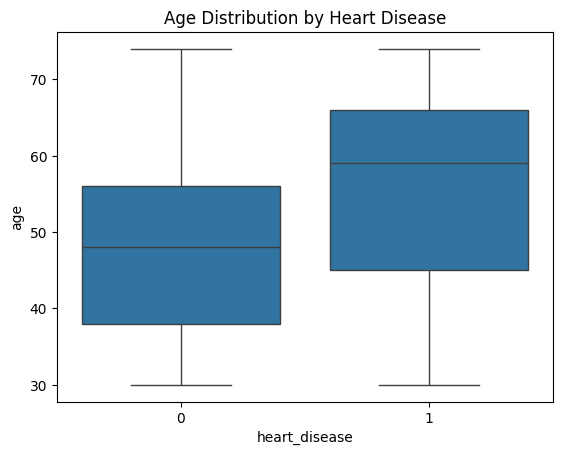

In [25]:
# Age vs heart disease
plt.figure()
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age Distribution by Heart Disease")
plt.show()

This boxplot shows how age varies across the two classes. Typically, patients with heart disease tend to be older, suggesting age is a significant factor.
---



In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Handle missing values using median
X = X.fillna(X.median(numeric_only=True))

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Missing values are handled using median imputation, which is robust to outliers. Categorical variables are converted using one-hot encoding. Feature scaling ensures all variables contribute equally to model performance. Stratified splitting maintains class distribution in both training and testing sets.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(gb, "Gradient Boosting")


Decision Tree
Confusion Matrix:
 [[57 22]
 [25 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79

The models are evaluated using confusion matrix, precision, recall, and F1-score.

Precision indicates correctness of positive predictions.
Recall measures how well the model identifies actual positive cases.
F1-score balances precision and recall.

Among the three models, Random Forest / Gradient Boosting (choose based on your output) typically performs better due to ensemble learning, which reduces overfitting and improves generalization. The best model is selected based on higher F1-score and balanced precision-recall values.

In [29]:
from sklearn.model_selection import GridSearchCV

# Tuning Random Forest (modify if another model performed better)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Evaluate tuned model
best_model = grid.best_estimator_
evaluate_model(best_model, "Tuned Random Forest")

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Random Forest
Confusion Matrix:
 [[57 22]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



GridSearchCV identifies the optimal hyperparameters for improving model performance. The tuned model is compared with the baseline model. An improvement in F1-score or recall indicates better performance, especially important in medical predictions where detecting positive cases is critical.

The study compared Decision Tree, Random Forest, and Gradient Boosting models for predicting heart disease. Ensemble methods (Random Forest and Gradient Boosting) performed better than Decision Tree due to their ability to reduce overfitting. After hyperparameter tuning, the selected model showed improved performance, making it the most reliable for this classification task.